WEEK 2 — Topic Modeling & Department Classification

Load data

In [8]:
# Cell 1: Load data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/grievances.csv')
df['clean_text'] = df['text'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)

X = df['clean_text']
y = df['department']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

TF-IDF Vectorization

In [9]:
# Cell 2: TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

Logistic Regression baseline

In [10]:
# Cell 3: Logistic Regression baseline
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

 Electricity       1.00      1.00      1.00        33
  Healthcare       1.00      1.00      1.00        37
       Roads       1.00      1.00      1.00        32
  Sanitation       1.00      1.00      1.00        32
   Transport       1.00      1.00      1.00        34
       Water       1.00      1.00      1.00        32

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Random Forest

In [11]:
# Cell 4: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

 Electricity       1.00      1.00      1.00        33
  Healthcare       1.00      1.00      1.00        37
       Roads       1.00      1.00      1.00        32
  Sanitation       1.00      1.00      1.00        32
   Transport       1.00      1.00      1.00        34
       Water       1.00      1.00      1.00        32

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Confusion Matrix (best model)

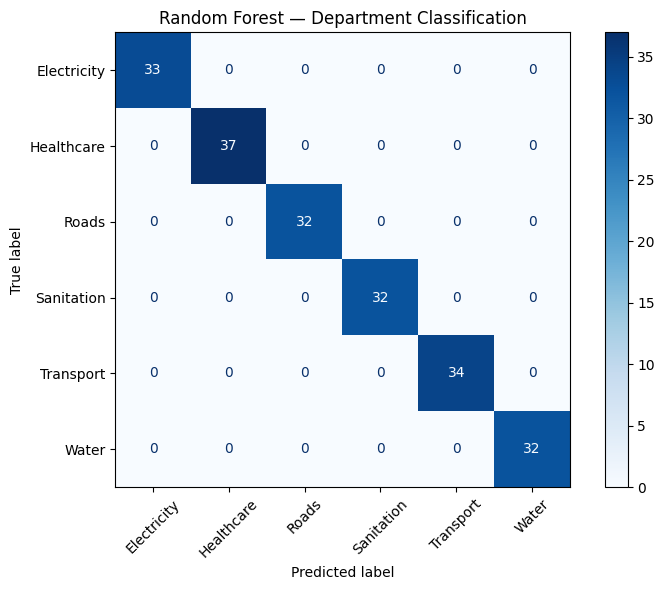

In [12]:
# Cell 5: Confusion Matrix (best model)
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=rf_model.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest — Department Classification')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/confusion_dept.png')
plt.show()

Save model & vectorizer

In [13]:
# Cell 6: Save model & vectorizer
import pickle

with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('../models/dept_classifier.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Models saved!")

Models saved!
